# PEM hydrogen production rate

Goal: estimate how much hydrogen the electrolyzer produces from electrical input.

For each charge-discharge test I use the charge part and calculate:

- `input_charge_C = integral(I_charge dt)`
- `input_energy_J = integral(V_charge I_charge dt)`
- `hydrogen_per_J = measured_hydrogen_volume_mL / input_energy_J`

The volume readings are manual, so I compare all tests and use an aggregate value rather than trusting
one single test.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# This makes the notebook work both from the repo root and from its own folder.
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "data").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not find the project root folder containing data/")
    PROJECT_ROOT = PROJECT_ROOT.parent

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 120)


## 1. Load volume readings and test files


In [3]:
readings_file = PROJECT_ROOT / "data/PEM_test/volume_readings/readings.csv"
pem_folder = PROJECT_ROOT / "data/PEM_test/charge_discharge"

volume_readings = pd.read_csv(readings_file)
test_files = sorted(pem_folder.glob("discharge_*s_r1.csv"))

display(volume_readings)
print("Test files:", len(test_files))


,current_A,time_s,volume_mL
0,0.2,30,0.2
1,0.2,60,1.6
2,0.2,120,3.0
3,0.3,30,1.6
4,0.3,60,2.2
5,0.3,120,4.2
6,0.4,30,2.2
7,0.4,60,4.0
8,0.4,120,6.0


Test files: 9


## 2. Extract the active electrolysis part of each file


In [4]:
def load_pem_charge_part(file):
    df = pd.read_csv(file)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["time_s"] = (df["timestamp"] - df["timestamp"].iloc[0]).dt.total_seconds()
    df["pem_voltage_V"] = df["ina4_bus_V"] - 0.064
    df["pem_current_A"] = 0.843 * (df["ina4_current_mA"] / 1000) + 0.001
    df["pem_charge_power_W"] = df["pem_voltage_V"] * df["pem_current_A"]

    charge = df[(df["scenario"] == 3) & (df["pem_current_A"] > 0.05)].copy()
    charge["charge_time_s"] = charge["time_s"] - charge["time_s"].iloc[0]
    return charge

charge_tests = {file.name: load_pem_charge_part(file) for file in test_files}

first_name = test_files[0].name
display(charge_tests[first_name].head())


,timestamp,scenario,mode,K1,K2,K3,K4,K5,K6,K7,ina1_ok,ina1_bus_V,ina1_current_mA,ina1_power_mW,ina1_shunt_mV,ina2_ok,ina2_bus_V,ina2_current_mA,ina2_power_mW,ina2_shunt_mV,ina3_ok,ina3_bus_V,ina3_current_mA,ina3_power_mW,ina3_shunt_mV,ina4_ok,ina4_bus_V,ina4_current_mA,ina4_power_mW,ina4_shunt_mV,time_s,pem_voltage_V,pem_current_A,pem_charge_power_W,charge_time_s
5,2026-04-30 09:11:12,3,Scenario 3: Grid -> Load; PV -> PEM,1,0,1,0,1,1,0,1,0.0,-0.025,0.0,-0.0025,1,0.0,-0.025,0.0,-0.0025,1,2.6525,198.525,526.875,19.8525,1,1.6662,236.175,393.750,23.6175,6.0,1.6022,0.200096,0.320593,0.0
6,2026-04-30 09:11:13,3,Scenario 3: Grid -> Load; PV -> PEM,1,0,1,0,1,1,0,1,0.0,-0.025,0.0,-0.0025,1,0.0,-0.025,0.0,-0.0025,1,2.6762,198.550,531.250,19.8550,1,1.6888,236.175,398.750,23.6175,7.0,1.6248,0.200096,0.325115,1.0
7,2026-04-30 09:11:14,3,Scenario 3: Grid -> Load; PV -> PEM,1,0,1,0,1,1,0,1,0.0,-0.025,0.0,-0.0025,1,0.0,-0.025,0.0,-0.0025,1,2.6775,198.575,531.875,19.8575,1,1.6888,236.200,398.750,23.6200,8.0,1.6248,0.200117,0.325149,2.0
8,2026-04-30 09:11:15,3,Scenario 3: Grid -> Load; PV -> PEM,1,0,1,0,1,1,0,1,0.0,-0.025,0.0,-0.0025,1,0.0,-0.025,0.0,-0.0025,1,2.6762,198.575,531.250,19.8575,1,1.6888,236.200,398.750,23.6200,9.0,1.6248,0.200117,0.325149,3.0
9,2026-04-30 09:11:16,3,Scenario 3: Grid -> Load; PV -> PEM,1,0,1,0,1,1,0,1,0.0,-0.025,0.0,-0.0025,1,0.0,-0.025,0.0,-0.0025,1,2.6737,198.625,531.250,19.8625,1,1.6875,236.200,398.125,23.6200,10.0,1.6235,0.200117,0.324889,4.0


## 3. Plot all charge areas to check the selected regions

Each line is one PEM charge test. This checks that the selected charging parts have the expected
duration and current level before the integration is done.


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

for file_name, charge in charge_tests.items():
    label = file_name.replace("discharge_", "").replace("_r1.csv", "")

    axes[0].plot(
        charge["charge_time_s"],
        charge["pem_current_A"],
        label=label,
    )
    axes[1].plot(
        charge["charge_time_s"],
        charge["pem_voltage_V"],
        label=label,
    )

axes[0].set_title("Selected PEM charge current for all tests")
axes[0].set_ylabel("PEM charge current [A]")
axes[0].grid(True)

axes[1].set_title("Selected PEM charge voltage for all tests")
axes[1].set_xlabel("Charge time [s]")
axes[1].set_ylabel("PEM charge voltage [V]")
axes[1].grid(True)

axes[0].legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()


## 4. Integrate charge and energy for every test


In [6]:
def parse_setpoints(file_name):
    # Example: discharge_040A_120s_r1.csv -> 0.40 A and 120 s.
    parts = file_name.replace(".csv", "").split("_")
    current_A = int(parts[1].replace("A", "")) / 100
    duration_s = int(parts[2].replace("s", ""))
    return current_A, duration_s

rows = []
for file_name, charge in charge_tests.items():
    current_setpoint_A, duration_setpoint_s = parse_setpoints(file_name)
    charge = charge.copy()
    charge["dt_s"] = charge["charge_time_s"].diff().fillna(0)
    input_charge_C = (charge["pem_current_A"] * charge["dt_s"]).sum()
    input_energy_J = (charge["pem_charge_power_W"] * charge["dt_s"]).sum()

    volume_match = volume_readings[
        (volume_readings["current_A"] == current_setpoint_A)
        & (volume_readings["time_s"] == duration_setpoint_s)
    ]
    hydrogen_volume_mL = volume_match["volume_mL"].iloc[0]

    rows.append(
        {
            "file": file_name,
            "current_setpoint_A": current_setpoint_A,
            "duration_setpoint_s": duration_setpoint_s,
            "hydrogen_volume_mL": hydrogen_volume_mL,
            "input_charge_C": input_charge_C,
            "input_energy_J": input_energy_J,
            "hydrogen_mL_per_C": hydrogen_volume_mL / input_charge_C,
            "hydrogen_mL_per_J": hydrogen_volume_mL / input_energy_J,
        }
    )

charge_summary = pd.DataFrame(rows).sort_values(["current_setpoint_A", "duration_setpoint_s"])
display(charge_summary)


,file,current_setpoint_A,duration_setpoint_s,hydrogen_volume_mL,input_charge_C,input_energy_J,hydrogen_mL_per_C,hydrogen_mL_per_J
1,discharge_020A_30s_r1.csv,0.2,30,0.2,5.999283,9.026946,0.033337,0.022156
2,discharge_020A_60s_r1.csv,0.2,60,1.6,11.999809,17.924721,0.133335,0.089262
0,discharge_020A_120s_r1.csv,0.2,120,3.0,23.635698,37.491836,0.126927,0.080017
4,discharge_030A_30s_r1.csv,0.3,30,1.6,8.699508,14.687808,0.183918,0.108934
5,discharge_030A_60s_r1.csv,0.3,60,2.2,17.983824,28.006290,0.122332,0.078554
3,discharge_030A_120s_r1.csv,0.3,120,4.2,35.737394,54.565123,0.117524,0.076972
7,discharge_040A_30s_r1.csv,0.4,30,2.2,11.979546,19.370871,0.183646,0.113573
8,discharge_040A_60s_r1.csv,0.4,60,4.0,24.001305,38.185626,0.166658,0.104751
6,discharge_040A_120s_r1.csv,0.4,120,6.0,47.939786,78.303592,0.125157,0.076625


## 5. Compare the rate values


Short-test aggregate H2 production: 0.0840 mL/J
Short-test aggregate H2 production: 0.1330 mL/C
Short-test coulomb efficiency:       104.9 %
A value above 100 percent means these small manual volume readings are noisy.


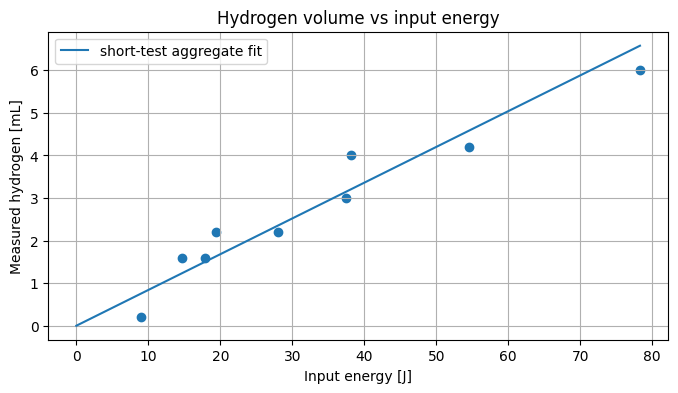

In [7]:
FARADAY_THEORETICAL_H2_ML_PER_C = 0.12678

SHORT_TEST_HYDROGEN_PRODUCTION_ML_PER_INPUT_J = (
    charge_summary["hydrogen_volume_mL"].sum() / charge_summary["input_energy_J"].sum()
)
SHORT_TEST_HYDROGEN_PRODUCTION_ML_PER_INPUT_C = (
    charge_summary["hydrogen_volume_mL"].sum() / charge_summary["input_charge_C"].sum()
)
SHORT_TEST_HYDROGEN_COULOMB_EFFICIENCY = (
    SHORT_TEST_HYDROGEN_PRODUCTION_ML_PER_INPUT_C / FARADAY_THEORETICAL_H2_ML_PER_C
)

print(f"Short-test aggregate H2 production: {SHORT_TEST_HYDROGEN_PRODUCTION_ML_PER_INPUT_J:.4f} mL/J")
print(f"Short-test aggregate H2 production: {SHORT_TEST_HYDROGEN_PRODUCTION_ML_PER_INPUT_C:.4f} mL/C")
print(f"Short-test coulomb efficiency:       {100 * SHORT_TEST_HYDROGEN_COULOMB_EFFICIENCY:.1f} %")
print("A value above 100 percent means these small manual volume readings are noisy.")

plt.figure(figsize=(8, 4))
plt.scatter(charge_summary["input_energy_J"], charge_summary["hydrogen_volume_mL"])
x = np.linspace(0, charge_summary["input_energy_J"].max(), 100)
plt.plot(x, SHORT_TEST_HYDROGEN_PRODUCTION_ML_PER_INPUT_J * x, label="short-test aggregate fit")
plt.title("Hydrogen volume vs input energy")
plt.xlabel("Input energy [J]")
plt.ylabel("Measured hydrogen [mL]")
plt.grid(True)
plt.legend()
plt.show()


## 6. Use the full 15.6 mL calibration for the EMS value

The short tests are useful for checking trends, but the volume readings are small and therefore noisy.
For the final EMS production constant I use the larger calibration from the polarization file.

Here I write the hydrogen estimate in the physical form:

- `Q = integral(I dt)`
- `E = integral(V I dt)`
- `H2_theoretical = Q * theoretical_H2_per_C`
- `eta = H2_observed / H2_theoretical`
- `H2_corrected = H2_theoretical * eta`
- `H2_per_C = theoretical_H2_per_C * eta`
- `H2_per_J = H2_corrected / E`
- `H2_rate = H2_corrected / charge_time`

This makes the efficiency correction explicit. Numerically, the corrected full-calibration hydrogen is
still 15.6 mL, because the efficiency factor is defined from the observed 15.6 mL value.


In [ ]:
polarization_file = PROJECT_ROOT / "data/PEM_test/current_sweep/PEM_polarization_characteristics.csv"
polarization = pd.read_csv(polarization_file)

polarization["timestamp"] = pd.to_datetime(polarization["timestamp"])
polarization["time_s"] = (polarization["timestamp"] - polarization["timestamp"].iloc[0]).dt.total_seconds()

polarization["pem_voltage_V"] = polarization["ina4_bus_V"] - 0.064
polarization["pem_current_A"] = 0.843 * (polarization["ina4_current_mA"] / 1000) + 0.001
polarization["pem_charge_power_W"] = polarization["pem_voltage_V"] * polarization["pem_current_A"]

charge_mask = (
    ((polarization["scenario"] == 3) | (polarization["pem_current_A"] > 0.01))
    & (polarization["pem_current_A"] > 0.05)
)

polarization_charge = polarization[charge_mask].copy()
polarization_charge["charge_time_s"] = polarization_charge["time_s"] - polarization_charge["time_s"].iloc[0]

# Formula: charge duration t = last selected charge time.
full_charge_duration_s = polarization_charge["charge_time_s"].iloc[-1]

# Formula: input charge Q = integral(I dt), unit C.
full_input_charge_C = np.trapezoid(
    polarization_charge["pem_current_A"],
    polarization_charge["charge_time_s"],
)

# Formula: input energy E = integral(P dt) = integral(V I dt), unit J.
full_input_energy_J = np.trapezoid(
    polarization_charge["pem_charge_power_W"],
    polarization_charge["charge_time_s"],
)

MEASURED_FULL_HYDROGEN_CAPACITY_ML = 15.6

# Formula: theoretical H2 = Q * theoretical_H2_per_C.
THEORETICAL_HYDROGEN_PRODUCTION_ML = full_input_charge_C * FARADAY_THEORETICAL_H2_ML_PER_C

# Formula: efficiency factor eta = observed H2 / theoretical H2.
OBSERVED_TO_THEORETICAL_EFFICIENCY = MEASURED_FULL_HYDROGEN_CAPACITY_ML / THEORETICAL_HYDROGEN_PRODUCTION_ML

# Formula: corrected H2 = theoretical H2 * eta.
CORRECTED_HYDROGEN_PRODUCTION_ML = THEORETICAL_HYDROGEN_PRODUCTION_ML * OBSERVED_TO_THEORETICAL_EFFICIENCY

# Formula: corrected H2 per input charge = theoretical_H2_per_C * eta.
HYDROGEN_PRODUCTION_ML_PER_INPUT_C = FARADAY_THEORETICAL_H2_ML_PER_C * OBSERVED_TO_THEORETICAL_EFFICIENCY

# Formula: corrected H2 per input energy = corrected H2 / input energy.
HYDROGEN_PRODUCTION_ML_PER_INPUT_J = CORRECTED_HYDROGEN_PRODUCTION_ML / full_input_energy_J

# Formula: average H2 charge rate = corrected H2 / charge duration.
HYDROGEN_CHARGE_RATE_ML_PER_S = CORRECTED_HYDROGEN_PRODUCTION_ML / full_charge_duration_s
HYDROGEN_CHARGE_RATE_ML_PER_MIN = HYDROGEN_CHARGE_RATE_ML_PER_S * 60

HYDROGEN_COULOMB_EFFICIENCY = OBSERVED_TO_THEORETICAL_EFFICIENCY

print(f"Full calibration charge duration: {full_charge_duration_s:.1f} s")
print(f"Full calibration input charge:    {full_input_charge_C:.2f} C")
print(f"Full calibration input energy:    {full_input_energy_J:.2f} J")
print(f"Theoretical H2 from charge:       {THEORETICAL_HYDROGEN_PRODUCTION_ML:.2f} mL")
print(f"Observed H2:                      {MEASURED_FULL_HYDROGEN_CAPACITY_ML:.2f} mL")
print(f"Efficiency factor eta:            {OBSERVED_TO_THEORETICAL_EFFICIENCY:.3f}")
print(f"Corrected H2:                     {CORRECTED_HYDROGEN_PRODUCTION_ML:.2f} mL")
print(f"EMS H2 production constant:       {HYDROGEN_PRODUCTION_ML_PER_INPUT_C:.5f} mL/C")
print(f"EMS H2 production constant:       {HYDROGEN_PRODUCTION_ML_PER_INPUT_J:.4f} mL/J")
print(f"Average H2 charge rate:           {HYDROGEN_CHARGE_RATE_ML_PER_S:.5f} mL/s")
print(f"Average H2 charge rate:           {HYDROGEN_CHARGE_RATE_ML_PER_MIN:.3f} mL/min")


## 7. Values to use in the EMS


In [ ]:
MAXIMUM_ELECTROLYSIS_CURRENT_A = charge_summary["current_setpoint_A"].max()
MINIMUM_CHARGE_TIME_BEFORE_USEFUL_DISCHARGE_S = charge_summary["duration_setpoint_s"].min()

charge_parameters = [
    ("MEASURED_FULL_HYDROGEN_CAPACITY_ML", MEASURED_FULL_HYDROGEN_CAPACITY_ML, "mL", "Observed full tank volume"),
    ("THEORETICAL_HYDROGEN_PRODUCTION_ML", THEORETICAL_HYDROGEN_PRODUCTION_ML, "mL", "Faraday hydrogen from charge"),
    ("OBSERVED_TO_THEORETICAL_EFFICIENCY", OBSERVED_TO_THEORETICAL_EFFICIENCY, "-", "Observed divided by theoretical"),
    ("CORRECTED_HYDROGEN_PRODUCTION_ML", CORRECTED_HYDROGEN_PRODUCTION_ML, "mL", "Theoretical hydrogen times efficiency"),
    ("HYDROGEN_PRODUCTION_ML_PER_INPUT_J", HYDROGEN_PRODUCTION_ML_PER_INPUT_J, "mL/J", "Corrected hydrogen per input energy"),
    ("HYDROGEN_PRODUCTION_ML_PER_INPUT_C", HYDROGEN_PRODUCTION_ML_PER_INPUT_C, "mL/C", "Corrected hydrogen per input charge"),
    ("HYDROGEN_CHARGE_RATE_ML_PER_S", HYDROGEN_CHARGE_RATE_ML_PER_S, "mL/s", "Average full-calibration charge rate"),
    ("HYDROGEN_CHARGE_RATE_ML_PER_MIN", HYDROGEN_CHARGE_RATE_ML_PER_MIN, "mL/min", "Average full-calibration charge rate"),
    ("SHORT_TEST_HYDROGEN_PRODUCTION_ML_PER_INPUT_J", SHORT_TEST_HYDROGEN_PRODUCTION_ML_PER_INPUT_J, "mL/J", "Noisy short-test comparison"),
    ("MAXIMUM_ELECTROLYSIS_CURRENT_A", MAXIMUM_ELECTROLYSIS_CURRENT_A, "A", "Largest tested electrolysis current"),
    ("MINIMUM_CHARGE_TIME_BEFORE_USEFUL_DISCHARGE_S", MINIMUM_CHARGE_TIME_BEFORE_USEFUL_DISCHARGE_S, "s", "Smallest tested charge duration"),
]

charge_parameters = pd.DataFrame(
    charge_parameters,
    columns=["parameter", "value", "unit", "meaning"],
)

display(charge_parameters)
